# Shepherd health-monitor analysis

**Where does the shepherd data live?** *Not* in the session `.h5`. Shepherd is an out-of-process
watchdog on the **leader** ([`shepherd/shepherd.py`](../shepherd/shepherd.py)); it writes one JSON
object per ~1 Hz sample to `~/shepherd_logs/shepherd_<launch-time>.jsonl` and a human-readable
`…​.alerts.log`. It is a **continuous** service, so one log spans many sessions plus idle time.

This notebook is **source-agnostic**:

- if the `.h5` has a `/health` group (the optional consolidation-time fold), it reads that;
- otherwise it reads a `shepherd_*.jsonl` — auto-discovered in the session folder, or fetched from
  the leader.

It aligns the health timeline to the **session window** (from the `.h5`), draws the shepherd
warn/critical thresholds (from `shepherd/config.yaml`), overlays the alerts that actually fired,
and prints during-session vs whole-log summary stats.

In [1]:
from pathlib import Path
import json, subprocess, re
from datetime import datetime, timezone
import numpy as np, pandas as pd
import h5py, yaml
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ── CONFIG ─────────────────────────────────────────────────────────────────────
# Point these at the session you want to analyse.
H5_PATH   = Path("/home/vruser/Desktop/VRFarm/data/HK1/HK1_20260819/HK1_20260819_001/"
                 "HK1_20260819_001.h5")
SESSION_DIR = H5_PATH.parent
REPO_ROOT   = Path("/home/vruser/VRFarm")
CONFIG_YAML = REPO_ROOT / "shepherd" / "config.yaml"   # for warn/critical threshold lines

# If no shepherd_*.jsonl is found locally, optionally scp it from the leader.
LEADER          = "vruser@192.168.10.101"
LEADER_LOG_DIR  = "~/shepherd_logs"
AUTO_FETCH      = True     # set False to stay fully offline

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True, "font.size": 10})
WARN_C, CRIT_C, SESS_C = "#e8a33d", "#d64545", "#3d7fe8"
print("Session:", H5_PATH.name, "| dir:", SESSION_DIR)

Session: HK1_20260819_001.h5 | dir: /home/vruser/Desktop/VRFarm/data/HK1/HK1_20260819/HK1_20260819_001


## 1 · Load the shepherd metrics (h5 `/health` if present, else JSONL)

In [2]:
HEALTH_COLS = ["t", "cpu_percent", "load1", "mem_percent", "mem_available_mb", "soc_temp_c",
               "disk_used_percent", "disk_free_gb", "disk_write_mbs",
               "api_ok", "api_latency_ms", "api_process_running", "api_camera_recording",
               "api_camera_fps", "thr_under_voltage_now", "thr_throttled_now",
               "thr_soft_temp_limit_now"]

def _flatten_record(m):
    '''One shepherd JSONL object -> a flat dict (nested api/throttled expanded).'''
    api = m.get("api") or {}
    thr = m.get("throttled") or {}
    return {
        "t": m.get("t"),
        "cpu_percent": m.get("cpu_percent"), "load1": m.get("load1"),
        "mem_percent": m.get("mem_percent"), "mem_available_mb": m.get("mem_available_mb"),
        "soc_temp_c": m.get("soc_temp_c"),
        "disk_used_percent": m.get("disk_used_percent"), "disk_free_gb": m.get("disk_free_gb"),
        "disk_write_mbs": m.get("disk_write_mbs"),
        "api_ok": api.get("ok"), "api_latency_ms": api.get("latency_ms"),
        "api_process_running": api.get("process_running"),
        "api_camera_recording": api.get("camera_recording"),
        "api_camera_fps": api.get("camera_fps"),
        "thr_under_voltage_now": thr.get("under_voltage_now"),
        "thr_throttled_now": thr.get("throttled_now"),
        "thr_soft_temp_limit_now": thr.get("soft_temp_limit_now"),
    }

def load_from_h5_health(h5_path):
    with h5py.File(h5_path, "r") as f:
        if "health" not in f:
            return None
        g = f["health"]
        data = {k: g[k][()] for k in g.keys()}
    df = pd.DataFrame(data)
    # bytes -> str for any object cols (h5 stores str as bytes)
    return df

def _overlaps(jsonl, lo, hi):
    '''True if this log's [t0,t1] overlaps the session window [lo,hi].'''
    try:
        first = json.loads(jsonl.open().readline())["t"]
        with jsonl.open() as fh:
            last = json.loads(fh.readlines()[-1])["t"]
        return not (last < lo or first > hi)
    except Exception:
        return False

def find_jsonl(session_dir, window=None):
    logs = sorted(Path(session_dir).glob("shepherd_*.jsonl"))
    if window:
        ov = [p for p in logs if _overlaps(p, *window)]
        if ov:
            return ov[-1]
    return logs[-1] if logs else None

def load_from_jsonl(jsonl):
    rows = []
    with open(jsonl) as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(_flatten_record(json.loads(line)))
    return pd.DataFrame(rows)

In [3]:
# Peek the session window early (needed to pick the overlapping log); full detail in §2.
with h5py.File(H5_PATH, "r") as f:
    _rt = f["trials/running_t"][()] if "trials/running_t" in f else None
_win = (float(np.min(_rt)), float(np.max(_rt))) if _rt is not None and _rt.size else None

df = load_from_h5_health(H5_PATH)
source = "h5:/health"
if df is None:
    jsonl = find_jsonl(SESSION_DIR, _win)
    if jsonl is None and AUTO_FETCH:
        print(f"No local shepherd log — fetching from {LEADER} …")
        subprocess.run(["scp", f"{LEADER}:{LEADER_LOG_DIR}/shepherd_*.jsonl",
                        f"{LEADER}:{LEADER_LOG_DIR}/shepherd_*.alerts.log", str(SESSION_DIR)+"/"],
                       check=False)
        jsonl = find_jsonl(SESSION_DIR, _win)
    if jsonl is None:
        raise FileNotFoundError("No /health group and no shepherd_*.jsonl found or fetchable.")
    df = load_from_jsonl(jsonl)
    source = jsonl.name

df = df.reindex(columns=[c for c in HEALTH_COLS if c in df.columns] +
                        [c for c in df.columns if c not in HEALTH_COLS])
df = df.sort_values("t").reset_index(drop=True)
t0 = float(df["t"].iloc[0])
df["min"] = (df["t"] - t0) / 60.0          # minutes since log start — the shared x-axis
print(f"source = {source}")
print(f"samples = {len(df)} | span = {(df['t'].iloc[-1]-t0)/60:.1f} min "
      f"| median dt = {np.median(np.diff(df['t'])):.2f} s")
df.head()

source = shepherd_20260819_090837.jsonl
samples = 3053 | span = 50.9 min | median dt = 1.00 s


,t,cpu_percent,load1,mem_percent,mem_available_mb,soc_temp_c,disk_used_percent,disk_free_gb,disk_write_mbs,api_ok,api_latency_ms,api_process_running,api_camera_recording,api_camera_fps,thr_under_voltage_now,thr_throttled_now,thr_soft_temp_limit_now,min
0,1.787127e+09,15.3,0.25,9.3,3671,46.9,2.1,472.7,0.0,True,1.7,False,False,NaN,False,False,False,0.000000
1,1.787127e+09,0.2,0.25,9.1,3679,45.8,2.1,472.7,0.0,True,1.4,False,False,NaN,False,False,False,0.016667
2,1.787127e+09,0.2,0.31,9.0,3686,45.8,2.1,472.7,0.0,True,1.4,False,False,NaN,False,False,False,0.033335
3,1.787127e+09,0.2,0.31,8.8,3692,45.2,2.1,472.7,0.0,True,1.8,False,False,NaN,False,False,False,0.050006
4,1.787127e+09,0.2,0.31,8.7,3698,44.6,2.1,472.7,0.0,True,1.7,False,False,NaN,False,False,False,0.066673


## 2 · Session window & camera facts (from the `.h5`)

In [4]:
def session_window(h5_path):
    '''Return dict: engine [start,end], camera-recording [start,end] (wall-clock s), measured_fps.'''
    out = {}
    with h5py.File(h5_path, "r") as f:
        if "trials/running_t" in f:
            rt = f["trials/running_t"][()]
            out["engine"] = (float(rt.min()), float(rt.max()))
        # camera recording window from frame wall-clock column (col 1); ignore unfilled 0 rows
        if "camera/frame_timestamps" in f:
            ft = f["camera/frame_timestamps"][()]
            wc = ft[:, 1]; wc = wc[wc > 0]
            if wc.size:
                out["camera"] = (float(wc.min()), float(wc.max()))
        cam = f["camera"].attrs if "camera" in f else {}
        out["measured_fps"]   = float(cam.get("measured_fps", np.nan))
        out["requested_fps"]  = float(cam.get("requested_fps", np.nan))
        out["frame_count"]    = int(cam.get("frame_count", 0))
        out["subject"]  = f.attrs.get("subject_id", "?")
        out["sess_id"]  = f.attrs.get("session_id", "?")
    return out

W = session_window(H5_PATH)
sess = W.get("engine") or W.get("camera")
s0, s1 = sess
sess_min = ((s0 - t0)/60.0, (s1 - t0)/60.0)   # session span on the shared x-axis
print(f"subject={W['subject']} session={W['sess_id']}")
print(f"engine window : {W.get('engine')}  ({(sess[1]-sess[0]):.0f} s ≈ {(sess[1]-sess[0])/60:.1f} min)")
print(f"camera window : {W.get('camera')}")
print(f"camera fps    : measured={W['measured_fps']:.2f}  requested={W['requested_fps']:.0f}  "
      f"frames={W['frame_count']}")
print(f"session sits at x = [{sess_min[0]:.1f}, {sess_min[1]:.1f}] min of the shepherd log")

subject=HK1 session=HK1_20260819_001
engine window : (1787127467.6888256, 1787128086.6637874)  (619 s ≈ 10.3 min)
camera window : (1787127466.4864998, 1787128086.662634)
camera fps    : measured=60.00  requested=60  frames=37213
session sits at x = [9.2, 19.5] min of the shepherd log


## 3 · Thresholds & the alerts that fired

In [5]:
def load_thresholds(path):
    try:
        cfg = yaml.safe_load(Path(path).read_text()) or {}
        return cfg.get("metrics", {})
    except Exception as e:
        print("threshold config unavailable, using fallback:", e)
        return {}

TH = load_thresholds(CONFIG_YAML)
FALLBACK = {  # matches shepherd/config.yaml at time of writing
    "soc_temp_c": dict(direction="high", warn=50, critical=70, unit="°C"),
    "cpu_percent": dict(direction="high", warn=85, critical=95, unit="%"),
    "mem_percent": dict(direction="high", warn=85, critical=95, unit="%"),
    "disk_used_percent": dict(direction="high", warn=80, critical=90, unit="%"),
    "disk_free_gb": dict(direction="low", warn=40, critical=15, unit="GB"),
    "disk_write_mbs": dict(direction="high", warn=80, critical=150, unit="MB/s"),
    "camera_fps": dict(direction="low", warn=45, critical=30, unit="fps"),
}
def thr(metric):
    return TH.get(metric) or FALLBACK.get(metric, {})

def derive_tz_offset(session_dir):
    '''Leader-tz offset (s) so the alerts log's local-ISO times convert to true unix,
    independently of the machine running this notebook. The shepherd log filename carries the
    launch time in the LEADER's local wall clock; its first JSONL sample carries the matching unix
    time. The difference (parsing the stamp as if UTC) IS the leader's UTC offset. Returns None if
    no jsonl is present to anchor on (then we fall back to this machine's local tz).'''
    logs = sorted(Path(session_dir).glob("shepherd_*.jsonl"))
    if logs:
        m = re.search(r"(\d{8}_\d{6})", logs[-1].name)
        try:
            first = json.loads(logs[-1].open().readline())["t"]
            if m:
                launch_as_utc = (datetime.strptime(m.group(1), "%Y%m%d_%H%M%S")
                                 .replace(tzinfo=timezone.utc).timestamp())
                return launch_as_utc - first
        except Exception:
            pass
    print("  (no jsonl to anchor tz — using this machine's local tz; alert alignment may shift "
          "if run off-rig)")
    return None

TZ_OFFSET = derive_tz_offset(SESSION_DIR)
if TZ_OFFSET is not None:
    print(f"  leader tz offset from log stamp: {TZ_OFFSET/3600:+.1f} h")

def _iso_to_unix(ts_s):
    '''Alerts-log ISO (leader local wall clock, tz-naive) -> true unix seconds.'''
    naive = datetime.fromisoformat(ts_s)
    if TZ_OFFSET is None:
        return naive.timestamp()                                   # this machine's local tz
    return naive.replace(tzinfo=timezone.utc).timestamp() - TZ_OFFSET

def load_alerts(session_dir):
    rows = []
    for p in sorted(Path(session_dir).glob("shepherd_*.alerts.log")):
        for line in p.read_text().splitlines():
            # "2026-08-19T09:08:46 [CRITICAL] metric: message"
            try:
                ts_s, rest = line.split(" ", 1)
                ts = _iso_to_unix(ts_s)                       # leader local ISO -> true unix
                lvl = rest[rest.index("[")+1:rest.index("]")].strip().lower()
                after = rest[rest.index("]")+1:].strip()
                metric, msg = (after.split(":", 1) + [""])[:2]
                rows.append(dict(t=ts, min=(ts - t0)/60.0, level=lvl,
                                 metric=metric.strip(), message=msg.strip()))
            except Exception:
                continue
    return pd.DataFrame(rows)

alerts = load_alerts(SESSION_DIR)
# alerts within the session window
in_sess = alerts[(alerts["t"] >= s0) & (alerts["t"] <= s1)] if len(alerts) else alerts
print(f"{len(alerts)} alert lines total; {len(in_sess)} during the session")
alerts[["min", "level", "metric", "message"]] if len(alerts) else "no alerts log found"

  leader tz offset from log stamp: +1.0 h
18 alert lines total; 11 during the session


,min,level,metric,message
0,0.150000,critical,api_health,pi_api not responding (<urlopen error [Errno 1...
1,0.216667,ok,api_health,pi_api responding again
2,8.733333,critical,api_health,pi_api not responding (<urlopen error [Errno 1...
3,8.783333,ok,api_health,pi_api responding again
4,9.166667,warning,camera_fps,Camera encode 41.9 fps — below target (encoder...
5,9.183333,ok,camera_fps,Camera encode fps recovered (60.1)
6,9.450000,warning,soc_temp_c,SoC temperature 50.1°C — running warm; check v...
7,9.466667,ok,soc_temp_c,SoC temperature back to normal (48.0°C)
8,9.566667,warning,soc_temp_c,SoC temperature 50.1°C — running warm; check v...
9,9.583333,ok,soc_temp_c,SoC temperature back to normal (49.0°C)


## 4 · Timeline

One shared x-axis (minutes since the shepherd log started). The **blue band** is the session;
dashed lines are the shepherd **warn** (orange) / **critical** (red) thresholds; small ticks at the
top of each panel mark **alerts** that fired (orange=warning, red=critical).

saved /home/vruser/Desktop/VRFarm/data/HK1/HK1_20260819/HK1_20260819_001/shepherd_health.png


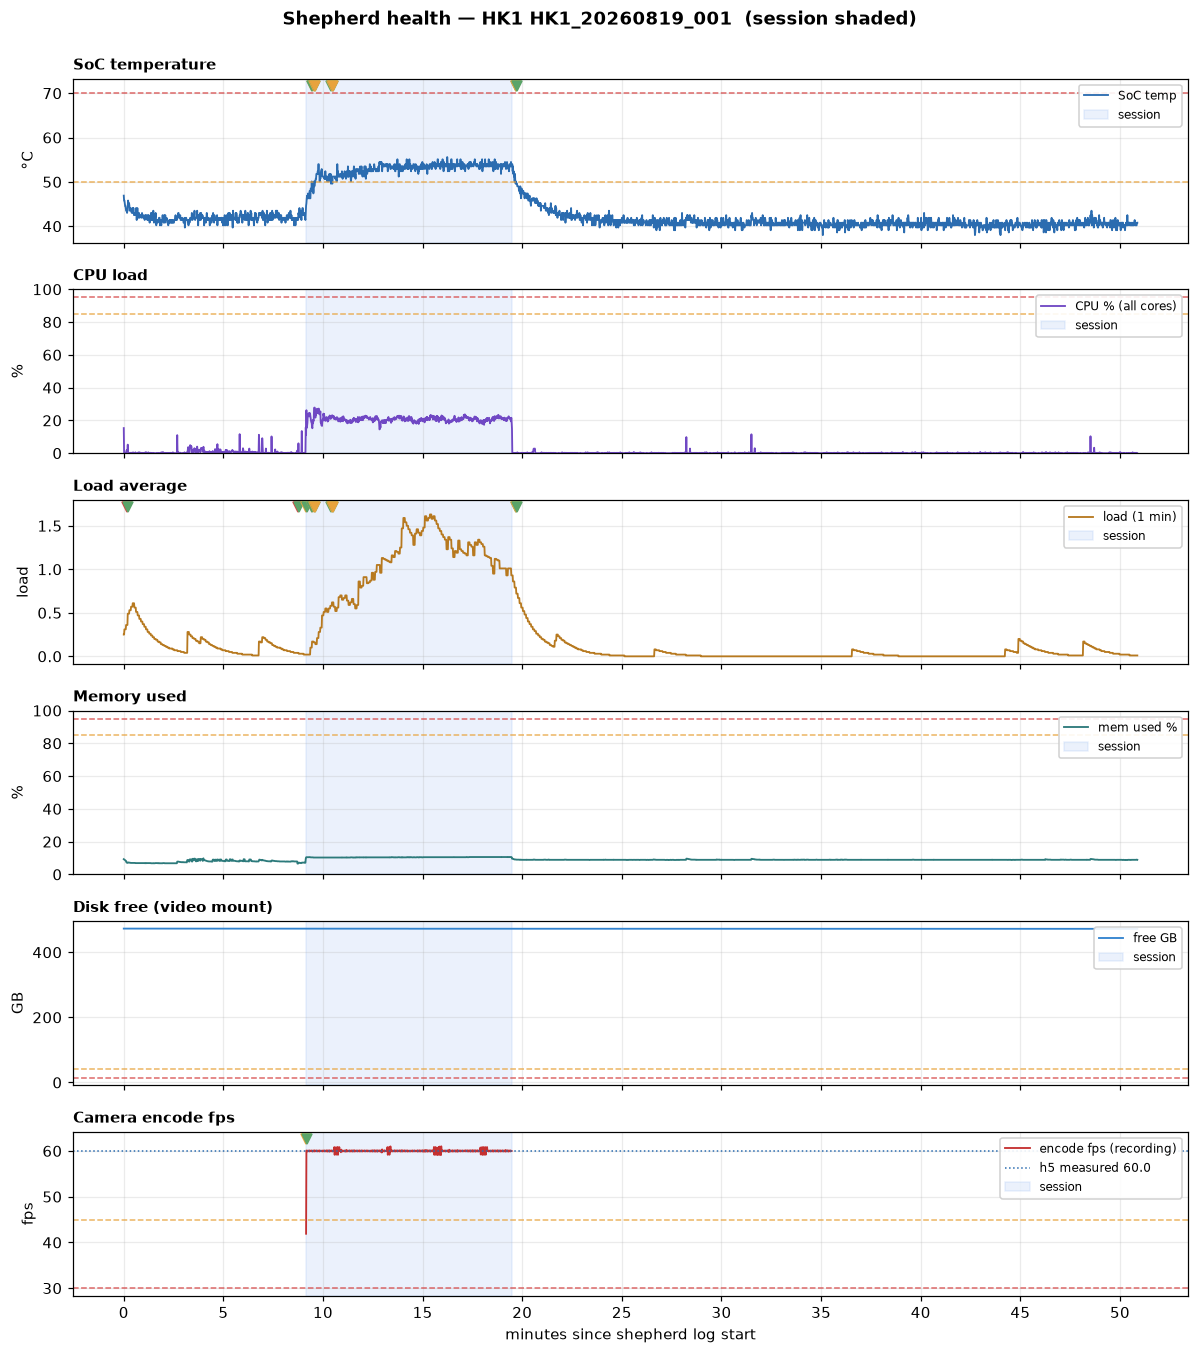

In [6]:
def decorate(ax, metric=None, alerts_metric="__self__"):
    '''Shade the session, draw this metric's warn/critical lines, and tick the alerts at the top.
    alerts_metric: "__self__" marks only alerts for `metric`; None marks ALL alerts (overview
    panel); or pass an explicit metric name.'''
    ax.axvspan(sess_min[0], sess_min[1], color=SESS_C, alpha=0.10, zorder=0, label="session")
    if metric:
        sp = thr(metric)
        for key, c in (("warn", WARN_C), ("critical", CRIT_C)):
            v = sp.get(key)
            if v is not None:
                ax.axhline(v, color=c, ls="--", lw=1, alpha=0.8)
    if len(alerts):
        which = metric if alerts_metric == "__self__" else alerts_metric
        sub = alerts if which is None else alerts[alerts["metric"] == which]
        ymax = ax.get_ylim()[1]
        for _, a in sub.iterrows():
            c = CRIT_C if a["level"] == "critical" else (WARN_C if a["level"] == "warning" else "#5aa469")
            ax.plot(a["min"], ymax, marker="v", color=c, ms=6, clip_on=False, zorder=5)

def line(ax, col, label, color="#2b6cb0"):
    d = df[["min", col]].dropna()
    ax.plot(d["min"], d[col], color=color, lw=1.2, label=label)

panels = 6
fig, axes = plt.subplots(panels, 1, figsize=(11, 2.05*panels), sharex=True)

# (a) SoC temperature — the headline
ax = axes[0]
line(ax, "soc_temp_c", "SoC temp")
ax.set_ylabel("°C"); ax.set_title("SoC temperature", loc="left", fontsize=10, fontweight="bold")
decorate(ax, "soc_temp_c")

# (b) CPU — aggregate + faint per-core (reconstructed if present)
ax = axes[1]
line(ax, "cpu_percent", "CPU % (all cores)", color="#7048c4")
ax.set_ylabel("%"); ax.set_ylim(0, 100)
ax.set_title("CPU load", loc="left", fontsize=10, fontweight="bold")
decorate(ax, "cpu_percent")

# (c) Load average
ax = axes[2]
line(ax, "load1", "load (1 min)", color="#b7791f")
ax.set_ylabel("load"); ax.set_title("Load average", loc="left", fontsize=10, fontweight="bold")
decorate(ax, None)

# (d) Memory used %
ax = axes[3]
line(ax, "mem_percent", "mem used %", color="#2c7a7b")
ax.set_ylabel("%"); ax.set_ylim(0, 100)
ax.set_title("Memory used", loc="left", fontsize=10, fontweight="bold")
decorate(ax, "mem_percent")

# (e) Disk free (GB)
ax = axes[4]
line(ax, "disk_free_gb", "free GB", color="#3182ce")
ax.set_ylabel("GB"); ax.set_title("Disk free (video mount)", loc="left", fontsize=10, fontweight="bold")
decorate(ax, "disk_free_gb")

# (f) Camera encode fps (only during recording) + measured target
ax = axes[5]
rec = df[df["api_camera_recording"] == True] if "api_camera_recording" in df else df.iloc[0:0]
d = rec[["min", "api_camera_fps"]].dropna()
ax.plot(d["min"], d["api_camera_fps"], color="#c53030", lw=1.2, label="encode fps (recording)")
if np.isfinite(W["measured_fps"]):
    ax.axhline(W["measured_fps"], color="#2b6cb0", ls=":", lw=1, label=f"h5 measured {W['measured_fps']:.1f}")
ax.set_ylabel("fps"); ax.set_title("Camera encode fps", loc="left", fontsize=10, fontweight="bold")
decorate(ax, "camera_fps")

axes[-1].set_xlabel("minutes since shepherd log start")
for ax in axes:
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    ax.xaxis.set_major_locator(MaxNLocator(12))
fig.suptitle(f"Shepherd health — {W['subject']} {W['sess_id']}  (session shaded)",
             fontsize=12, fontweight="bold", y=0.997)
fig.tight_layout()
out_png = SESSION_DIR / "shepherd_health.png"
fig.savefig(out_png, bbox_inches="tight", dpi=130)
print("saved", out_png)
plt.show()

## 5 · Zoom: the session only

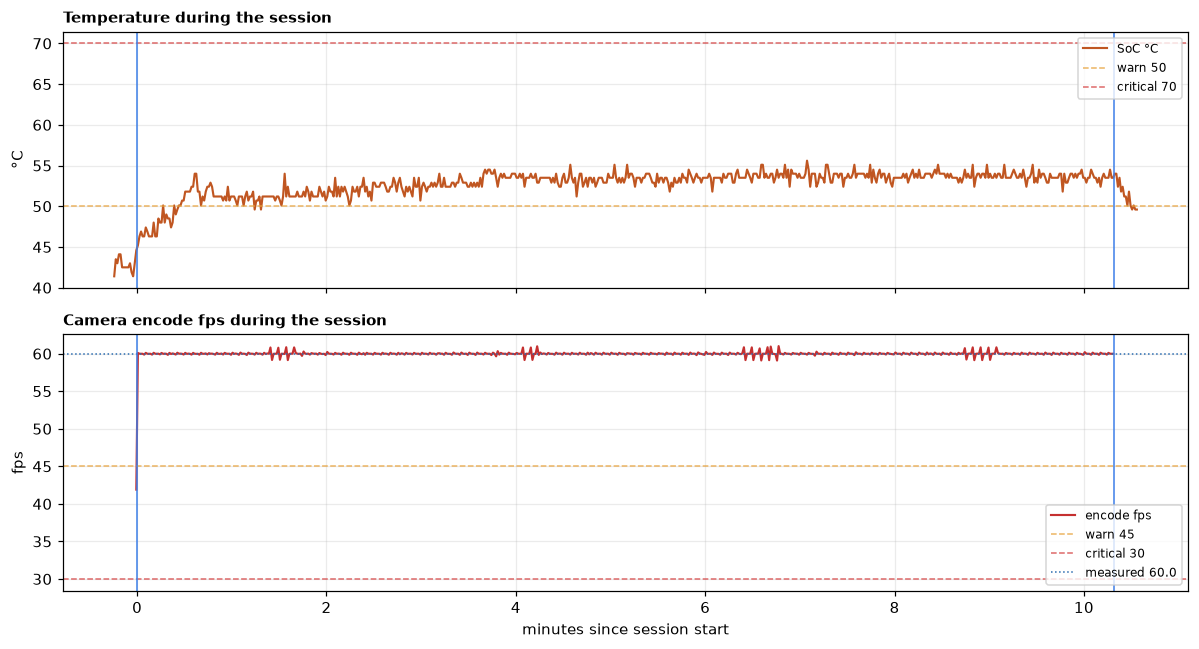

In [7]:
zoom = df[(df["t"] >= s0 - 15) & (df["t"] <= s1 + 15)].copy()   # ±15 s pad
zoom["sess_min"] = (zoom["t"] - s0) / 60.0
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax[0].plot(zoom["sess_min"], zoom["soc_temp_c"], color="#c05621", lw=1.4, label="SoC °C")
sp = thr("soc_temp_c")
for k, c in (("warn", WARN_C), ("critical", CRIT_C)):
    if sp.get(k) is not None: ax[0].axhline(sp[k], color=c, ls="--", lw=1, alpha=.8, label=f"{k} {sp[k]}")
ax[0].set_ylabel("°C"); ax[0].set_title("Temperature during the session", loc="left",
                                        fontsize=10, fontweight="bold")
ax[0].legend(loc="upper right", fontsize=8)

recz = zoom[zoom["api_camera_recording"] == True] if "api_camera_recording" in zoom else zoom
ax[1].plot(recz["sess_min"], recz["api_camera_fps"], color="#c53030", lw=1.4, label="encode fps")
spf = thr("camera_fps")
for k, c in (("warn", WARN_C), ("critical", CRIT_C)):
    if spf.get(k) is not None: ax[1].axhline(spf[k], color=c, ls="--", lw=1, alpha=.8, label=f"{k} {spf[k]}")
if np.isfinite(W["measured_fps"]):
    ax[1].axhline(W["measured_fps"], color="#2b6cb0", ls=":", lw=1, label=f"measured {W['measured_fps']:.1f}")
ax[1].set_ylabel("fps"); ax[1].set_xlabel("minutes since session start")
ax[1].set_title("Camera encode fps during the session", loc="left", fontsize=10, fontweight="bold")
ax[1].legend(loc="lower right", fontsize=8)
for a in ax:
    a.axvline(0, color=SESS_C, lw=1); a.axvline((s1-s0)/60, color=SESS_C, lw=1)
fig.tight_layout(); plt.show()

## 6 · Summary — during-session vs whole log

In [8]:
def stats(frame, cols):
    rows = {}
    for c in cols:
        if c in frame and frame[c].notna().any():
            s = frame[c].astype(float)
            rows[c] = [s.min(), s.median(), s.quantile(0.95), s.max()]
        else:
            rows[c] = [np.nan]*4
    return pd.DataFrame(rows, index=["min", "median", "p95", "max"]).T

metrics = ["soc_temp_c", "cpu_percent", "load1", "mem_percent", "disk_free_gb",
           "disk_used_percent", "api_latency_ms"]
sess_df = df[(df["t"] >= s0) & (df["t"] <= s1)]

summary = stats(sess_df, metrics).add_suffix(" · session").join(
          stats(df, metrics).add_suffix(" · full"))
print("Per-metric summary (session window vs whole log):")
display(summary.round(2))

# camera fps during recording
rec = sess_df[sess_df.get("api_camera_recording") == True] if "api_camera_recording" in sess_df else sess_df.iloc[0:0]
fps = rec["api_camera_fps"].dropna()
print("\n── Session headline ──")
print(f"peak SoC temp     : {sess_df['soc_temp_c'].max():.1f} °C "
      f"(warn {thr('soc_temp_c').get('warn')}, crit {thr('soc_temp_c').get('critical')})")
if len(fps):
    print(f"encode fps        : min {fps.min():.1f} / median {fps.median():.1f} "
          f"(target {W['measured_fps']:.1f}); below-warn samples: {(fps < thr('camera_fps').get('warn',45)).sum()}")
thr_cols = [c for c in ("thr_throttled_now","thr_under_voltage_now","thr_soft_temp_limit_now") if c in sess_df]
n_thr = int(sess_df[thr_cols].fillna(False).astype(bool).any(axis=1).sum()) if thr_cols else 0
print(f"throttle samples  : {n_thr} during session")
if len(alerts):
    print(f"alerts in session : {len(in_sess)}  "
          f"({', '.join(sorted(set(in_sess['metric']))) if len(in_sess) else 'none'})")

Per-metric summary (session window vs whole log):


,min · session,median · session,p95 · session,max · session,min · full,median · full,p95 · full,max · full
soc_temp_c,45.20,53.50,54.50,55.60,38.0,41.40,54.00,55.60
cpu_percent,14.50,20.80,23.21,27.80,0.0,0.20,21.80,27.80
load1,0.02,1.12,1.56,1.63,0.0,0.05,1.31,1.63
mem_percent,10.30,10.50,10.60,10.60,6.6,8.90,10.50,10.60
disk_free_gb,472.00,472.30,472.60,472.70,472.0,472.00,472.70,472.70
disk_used_percent,2.10,2.20,2.20,2.20,2.1,2.20,2.20,2.20
api_latency_ms,1.50,2.00,2.80,8.30,1.1,1.60,2.40,87.10



── Session headline ──
peak SoC temp     : 55.6 °C (warn 50, crit 70)
encode fps        : min 59.1 / median 60.0 (target 60.0); below-warn samples: 0
throttle samples  : 0 during session
alerts in session : 11  (camera_fps, soc_temp_c)


---
### Notes
- **fps only exists while recording** — shepherd derives it from the pi_api `camera_frames`
  counter, so the encode-fps panel is populated only inside the recording window.
- **`pi_api` blips** appear as `api_health` alerts and are usually a Deploy/Install restarting the
  service, not a mid-run wedge — cross-check the alert time against the session window.
- To analyse a different session, change `H5_PATH` in the config cell. If its shepherd log isn't in
  the folder, `AUTO_FETCH` scp's it from the leader (needs the log still present there).
- If you adopt the consolidation-time `/health` fold, this notebook will silently prefer it and no
  longer need the leader.